# Volve Well - Well-Log Data Loading and Quality Control

## Purpose

This notebook first ask whether the tools measured the rock reliably, before interpreting what the rock and fluids are.

The raw measurements are never deleted or overwritten. 
A separate `qc_df` dataframe keeps the original curves and adds quality-control flags.

## Questions answered

1. What curves are available?
2. At what depths are they available?
3. Are there missing values or internal gaps?
4. Is the borehole enlarged?
5. Can the density measurement be trusted?
6. Are density–neutron anomalies associated with poor borehole conditions, or do they remain geological candidates for later interpretation?
7. Which resistivity curves duplicate one another?
8. Which rows are suitable inputs for the next formation-evaluation notebook?


## Notebook workflow

```text
Load LAS file
    ↓
Preserve raw data
    ↓
Check well data and depth continuity
    ↓
Inventory curves, units, coverage and missing values
    ↓
Screen data ranges for curves
    ↓
Create borehole and density-reliability flags
    ↓
Review density–neutron response by QC class
    ↓
Compare resistivity curves for duplication
    ↓
Mark rows suitable for later interpretation
    ↓
Export all curves together with QC flags
```


In [1]:
# Cell 1: Import libraries and define file locations


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import lasio

LAS_FILENAME = "WLC_PETRO_COMPUTED_INPUT_1.LAS"
FILEPATH = Path(LAS_FILENAME)

# File names are case-sensitive on Linux and GitHub.
# If the exact spelling is not found, look for the same name with different letter case.
if not FILEPATH.exists():
    matching_files = [
        path
        for path in Path.cwd().iterdir()
        if path.name.lower() == LAS_FILENAME.lower()
    ]

    if matching_files:
        FILEPATH = matching_files[0]

RESULTS_DIR = Path("results") # create Folders for tables and images exported from this notebook
IMAGES_DIR = Path("images")

RESULTS_DIR.mkdir(exist_ok=True)
IMAGES_DIR.mkdir(exist_ok=True)

if not FILEPATH.exists():
    raise FileNotFoundError(
        f"LAS file not found: {FILEPATH.resolve()}\n"
        "Place WLC_PETRO_COMPUTED_INPUT_1.LAS in the same folder as the notebook."
    )

print(f"LAS file found: {FILEPATH.resolve()}")

LAS file found: C:\Users\linda\OneDrive\Data Analyst Work\Well-log-qc\1\WLC_PETRO_COMPUTED_INPUT_1.LAS


In [2]:
# Cell 2: Load the LAS file and preserve the raw data


def load_las(filepath):
    """Read a LAS file and return a dataframe plus the LAS object."""

    las = lasio.read(str(filepath))

    # las.df() places depth in the index.
    # reset_index() moves depth back into a normal dataframe column.
    well_df = las.df().reset_index()

    # Rename the first column consistently as DEPTH.
    well_df = well_df.rename(columns={well_df.columns[0]: "DEPTH"})

    # Remove spaces and standardise column names to upper case.
    well_df.columns = [
        str(column).strip().upper()
        for column in well_df.columns
    ]

    # LAS files use a special number for missing data, commonly -999.25. lasio normally converts this to NaN,
    # this replacement is repeated here as a double check.
    null_value = (
        las.well["NULL"].value
        if "NULL" in las.well
        else -999.25
    )

    well_df = well_df.replace(
        [null_value, -999.25],
        np.nan
    )

    return well_df, las


raw_df, las = load_las(FILEPATH) # raw_df remains the untouched numerical dataset.

# Save a simple fingerprint of the raw dataframe.
# This shows no raw rows or columns were deleted.
RAW_ROW_COUNT = len(raw_df)
RAW_COLUMN_NAMES = raw_df.columns.tolist()

qc_df = raw_df.copy(deep=True) # qc_df is the working copy to which QC columns will be added.

print(f"Rows loaded:    {len(raw_df):,}")
print(f"Columns loaded: {raw_df.shape[1]}")
print(f"Depth range:    {raw_df['DEPTH'].min():.1f}–{raw_df['DEPTH'].max():.1f} m")

raw_df.head()

Rows loaded:    34,861
Columns loaded: 21
Depth range:    145.9–3631.9 m


,DEPTH,ABDCQF01,ABDCQF02,ABDCQF03,ABDCQF04,BS,CALI,DRHO,DT,GR,...,PEF,RACEHM,RACELM,RD,RHOB,RM,ROP,RPCEHM,RPCELM,RT
0,145.9,NaN,NaN,NaN,NaN,36.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,146.0,NaN,NaN,NaN,NaN,36.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,146.1,NaN,NaN,NaN,NaN,36.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,146.2,NaN,NaN,NaN,NaN,36.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,146.3,NaN,NaN,NaN,NaN,36.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### NOTE — in simple English

The LAS file is the well log data. Two copies are made:

- `raw_df` is the protected copy. It is kept unchanged.
- `qc_df` is the working copy. All warnings and reliability labels are added here.

Hence a suspicious value can be marked or flagged without destroying the original file

### 1. Confirm the well information 

This is same as checking the label of a sample bag digitally. It confirms the company, well, field, depth range, sampling step and missing-value code before the measurements are analysed.

In [3]:
# Cell 3: Confirm the well information
#  This checks that the intended well was loaded and records the important well data from the LAS header


def read_header_value(section, mnemonic, default=np.nan):
    """Safely read a value from a LAS header section."""

    if mnemonic in section:
        return section[mnemonic].value

    return default


well_metadata = pd.DataFrame(
    {
        "ITEM": [
            "Company",
            "Well",
            "Field",
            "Location",
            "Start depth (m)",
            "Stop depth (m)",
            "Nominal depth step (m)",
            "LAS null value"
        ],
        "VALUE": [
            read_header_value(las.well, "COMP"),
            read_header_value(las.well, "WELL"),
            read_header_value(las.well, "FLD"),
            read_header_value(las.well, "LOC"),
            read_header_value(las.well, "STRT"),
            read_header_value(las.well, "STOP"),
            read_header_value(las.well, "STEP"),
            read_header_value(las.well, "NULL")
        ]
    }
)

well_metadata


,ITEM,VALUE
0,Company,Statoil Petroleum
1,Well,15/9-F-1
2,Field,VOLVE
3,Location,Maersk Inspirer
4,Start depth (m),145.9
5,Stop depth (m),3631.9
6,Nominal depth step (m),0.1
7,LAS null value,-999.25


### 2. Check and QC depth column

A valid depth coloumn is defined by:
- increase down the well
- contain no duplicate depths
- use the expected sampling step
- contain no unexplained jumps

### Why depth QC ?
Depth is the measurement used to line up the remaining logs. The notebook checks that the depth increases downward normally, does not repeat the same values, and does not suddenly jump over an interval. A depth problem can make curves appear to match the wrong rock layer.


In [4]:
# Cell 4: Depth continuityand duplicate-depth QC

expected_depth_step = abs(
    float(
        read_header_value(
            las.well,
            "STEP",
            raw_df["DEPTH"].diff().median()
        )
    )
)

qc_df["DEPTH_STEP_M"] = qc_df["DEPTH"].diff()

# Row-level flags are retained so the exact depths can be inspected later.
qc_df["MISSING_DEPTH_FLAG"] = qc_df["DEPTH"].isna()

qc_df["DUPLICATE_DEPTH_FLAG"] = qc_df[
    "DEPTH"
].duplicated(
    keep=False
)

qc_df["NON_INCREASING_DEPTH_FLAG"] = False

qc_df.loc[
    qc_df["DEPTH_STEP_M"].notna(),
    "NON_INCREASING_DEPTH_FLAG"
] = (
    qc_df.loc[
        qc_df["DEPTH_STEP_M"].notna(),
        "DEPTH_STEP_M"
    ]
    <=
    0
)

valid_positive_depth_step = (
    qc_df["DEPTH_STEP_M"].notna()
    &
    (qc_df["DEPTH_STEP_M"] > 0)
)

# Use a small tolerance because decimal depth values can contain tiny computer-rounding differences.
depth_step_tolerance = max(
    1e-6,
    expected_depth_step * 1e-4
)

qc_df["DEPTH_GAP_FLAG"] = False

qc_df.loc[
    valid_positive_depth_step,
    "DEPTH_GAP_FLAG"
] = ~np.isclose(
    qc_df.loc[
        valid_positive_depth_step,
        "DEPTH_STEP_M"
    ],
    expected_depth_step,
    rtol=0,
    atol=depth_step_tolerance
)

duplicate_depth_count = int(
    qc_df["DUPLICATE_DEPTH_FLAG"].sum()
)

non_increasing_depth_count = int(
    qc_df["NON_INCREASING_DEPTH_FLAG"].sum()
)

unexpected_depth_step_count = int(
    qc_df["DEPTH_GAP_FLAG"].sum()
)

depth_qc_summary = pd.DataFrame(
    {
        "CHECK": [
            "Expected depth step",
            "Missing depth values",
            "Rows involved in duplicate depths",
            "Non-increasing depth rows",
            "Unexpected positive depth steps"
        ],
        "RESULT": [
            f"{expected_depth_step:.4f} m",
            int(qc_df["MISSING_DEPTH_FLAG"].sum()),
            duplicate_depth_count,
            non_increasing_depth_count,
            unexpected_depth_step_count
        ]
    }
)

depth_qc_summary

,CHECK,RESULT
0,Expected depth step,0.1000 m
1,Missing depth values,0
2,Rows involved in duplicate depths,0
3,Non-increasing depth rows,0
4,Unexpected positive depth steps,0


### 3. Inventory the available curves 

Data limitation:
The available Volve file is a composite petrophysical-input LAS file. Its curve descriptions has identifiers such as `COMPOSITE:rC:NONE:v1`, and no metadata (descriptions). `lasio` therefore displayed `v1` for many descriptions.

The notebook keep the original header inventory, then adds a reference table based on:
- mnemonic
- unit
- numerical behaviour
- data coverage
- known petrophysical use


In [5]:
# Cell 5: Build the curve inventory supplied by the LAS header

pd.set_option("display.max_colwidth", None)

header_curve_inventory = pd.DataFrame(
    [
        {
            "RAW_MNEMONIC": curve.mnemonic.upper(),
            "UNIT": curve.unit,
            "HEADER_DESCRIPTION": curve.descr
        }
        for curve in las.curves
    ]
)

header_curve_inventory


,RAW_MNEMONIC,UNIT,HEADER_DESCRIPTION
0,DEPTH,M,0 Depth
1,ABDCQF01,g/cm3,v1
2,ABDCQF02,g/cm3,v1
3,ABDCQF03,g/cm3,v1
4,ABDCQF04,g/cm3,v1
5,BS,inches,v1
6,CALI,inches,v1
7,DRHO,g/cm3,v1
8,DT,us/ft,v1
9,GR,API,v1


In [6]:
# Cell 6: Add a documented log-reference table and group the curves by their purpose
# curves to be used in notebook 1 marked with a yes, change as and when needed 

curve_reference = pd.DataFrame(
    [
        ["DEPTH", "Measured depth", "Depth reference", "Depth", "Yes"],
        ["BS", "Bit size", "Expected drilled-hole diameter", "Borehole QC", "Yes"],
        ["CALI", "Caliper", "Measured borehole diameter", "Borehole QC", "Yes"],
        ["DRHO", "Density correction", "Supporting check on RHOB reliability", "Density QC", "Yes"],
        ["GR", "Gamma ray", "Later shale-volume input and broad curve QC", "Primary interpretation", "Yes"],
        ["RHOB", "Bulk density", "Later density-porosity input", "Primary interpretation", "Yes"],
        ["NPHI", "Neutron porosity", "Later porosity and density–neutron analysis", "Primary interpretation", "Yes"],
        ["RT", "Composite resistivity", "Primary later saturation input", "Primary interpretation", "Yes"],
        ["DT", "Compressional sonic slowness", "Supporting rock-property curve", "Supporting log", "Yes"],
        ["PEF", "Photoelectric factor", "Supporting lithology curve", "Supporting log", "Yes"],
        ["ROP", "Rate of penetration", "Supporting drilling-response curve", "Supporting log", "Optional"],
        ["RACEHM", "Composite resistivity candidate", "Resistivity comparison and QC", "Resistivity comparison", "Yes"],
        ["RACELM", "Composite resistivity candidate", "Resistivity comparison and QC", "Resistivity comparison", "Yes"],
        ["RD", "Additional composite resistivity", "Resistivity comparison and QC", "Resistivity comparison", "Yes"],
        ["RM", "Additional composite resistivity", "Resistivity comparison and QC", "Resistivity comparison", "Yes"],
        ["RPCEHM", "Composite resistivity candidate", "Resistivity comparison and QC", "Resistivity comparison", "Yes"],
        ["RPCELM", "Composite resistivity candidate", "Resistivity comparison and QC", "Resistivity comparison", "Yes"],
        ["ABDCQF01", "Unresolved density-unit composite curve", "Preserve; exact metadata not supplied", "Unresolved metadata", "No"],
        ["ABDCQF02", "Unresolved density-unit composite curve", "Preserve; exact metadata not supplied", "Unresolved metadata", "No"],
        ["ABDCQF03", "Unresolved density-unit composite curve", "Preserve; exact metadata not supplied", "Unresolved metadata", "No"],
        ["ABDCQF04", "Unresolved density-unit composite curve", "Preserve; exact metadata not supplied", "Unresolved metadata", "No"]
    ],
    columns=[
        "RAW_MNEMONIC",
        "PLAIN_ENGLISH_NAME",
        "PROJECT_ROLE",
        "LOG_GROUP",
        "USE_IN_NOTEBOOK_1"
    ]
)

curve_reference


,RAW_MNEMONIC,PLAIN_ENGLISH_NAME,PROJECT_ROLE,LOG_GROUP,USE_IN_NOTEBOOK_1
0,DEPTH,Measured depth,Depth reference,Depth,Yes
1,BS,Bit size,Expected drilled-hole diameter,Borehole QC,Yes
2,CALI,Caliper,Measured borehole diameter,Borehole QC,Yes
3,DRHO,Density correction,Supporting check on RHOB reliability,Density QC,Yes
4,GR,Gamma ray,Later shale-volume input and broad curve QC,Primary interpretation,Yes
5,RHOB,Bulk density,Later density-porosity input,Primary interpretation,Yes
6,NPHI,Neutron porosity,Later porosity and density–neutron analysis,Primary interpretation,Yes
7,RT,Composite resistivity,Primary later saturation input,Primary interpretation,Yes
8,DT,Compressional sonic slowness,Supporting rock-property curve,Supporting log,Yes
9,PEF,Photoelectric factor,Supporting lithology curve,Supporting log,Yes


In [7]:
# Cell 7: Group the curves by their QC purpose and verify that they exist
# this is to help with easier crossplotting and qc. example the borehole qc, density qc, primary interpretation, etc. 

curve_groups = {
    "depth": [ "DEPTH"],
    "borehole_qc": [  "BS", "CALI"  ],
    "density_qc": [ "RHOB",  "DRHO",  "NPHI"   ],
    "primary_interpretation": [ "BS", "CALI","GR", "RHOB", "NPHI", "RT"   ],
    "supporting_logs": [ "DT", "PEF", "ROP"  ],
    "resistivity_comparison": [ "RACEHM",  "RACELM",  "RD",  "RM", "RPCEHM", "RPCELM","RT"],
    "unresolved_metadata": [  "ABDCQF01",  "ABDCQF02",  "ABDCQF03",  "ABDCQF04"   ]
}

expected_curves = sorted(
    {
        curve
        for group in curve_groups.values()
        for curve in group
    }
)

missing_expected_curves = [
    curve
    for curve in expected_curves
    if curve not in raw_df.columns
]

if missing_expected_curves:
    print("Expected curves not found:")
    print(missing_expected_curves)
else:
    print("All expected project curves were found in the LAS file.")

curve_groups


All expected project curves were found in the LAS file.


{'depth': ['DEPTH'],
 'borehole_qc': ['BS', 'CALI'],
 'density_qc': ['RHOB', 'DRHO', 'NPHI'],
 'primary_interpretation': ['BS', 'CALI', 'GR', 'RHOB', 'NPHI', 'RT'],
 'supporting_logs': ['DT', 'PEF', 'ROP'],
 'resistivity_comparison': ['RACEHM',
  'RACELM',
  'RD',
  'RM',
  'RPCEHM',
  'RPCELM',
  'RT'],
 'unresolved_metadata': ['ABDCQF01', 'ABDCQF02', 'ABDCQF03', 'ABDCQF04']}

### Metadata and unit checks

checks the unit and records information that the LAS header does not provide.This matters because:
- a correct number in the wrong unit can produce a wrong calculation
- tool-specific environmental corrections cannot be reconstructed when the tool model, mud type or correction history is missing
- alternative resistivity curves cannot honestly be labelled “deep” or “shallow” without their investigation-depth metadata

In [8]:
# Extra QC: document metadata limitations and check expected units

metadata_limitations = pd.DataFrame(
    {
        "ITEM": [
            "Exact logging-tool models",
            "Mud type",
            "Mud density",
            "Barite presence",
            "Environmental-correction history",
            "Investigation depth of each resistivity curve",
            "Independent source-run depth matching"
        ],
        "STATUS": [
            "Not fully defined in LAS header",
            "Not defined in LAS header",
            "Not defined in LAS header",
            "Unknown",
            "Composite curves supplied; full correction history unavailable",
            "Not fully defined",
            "Composite file appears matched; raw runs unavailable"
        ],
        "QC_IMPLICATION": [
            "Tool-specific corrections cannot be reproduced",
            "Mud effects on GR, NPHI, density and PEF cannot be fully quantified",
            "Radiation attenuation cannot be quantified",
            "PEF reliability cannot be fully certified",
            "Supplied curves are assessed rather than re-corrected",
            "Deep and shallow labels cannot be assigned confidently",
            "Independent run-to-run depth matching cannot be verified"
        ]
    }
)

EXPECTED_UNITS = {
    "DEPTH": "m",
    "BS": "inches",
    "CALI": "inches",
    "DRHO": "g/cm3",
    "DT": "us/ft",
    "GR": "API",
    "NPHI": "v/v",
    "PEF": "b/elec",
    "RACEHM": "ohm.m",
    "RACELM": "ohm.m",
    "RD": "ohm.m",
    "RHOB": "g/cm3",
    "RM": "ohm.m",
    "ROP": "m/hr",
    "RPCEHM": "ohm.m",
    "RPCELM": "ohm.m",
    "RT": "ohm.m"
}


def normalise_unit(unit):
    """Make harmless formatting differences comparable."""

    return (
        str(unit)
        .strip()
        .lower()
        .replace("µ", "u")
        .replace("³", "3")
        .replace(" ", "")
    )


unit_qc = (
    header_curve_inventory[
        [
            "RAW_MNEMONIC",
            "UNIT"
        ]
    ]
    .rename(
        columns={
            "UNIT": "ACTUAL_UNIT"
        }
    )
    .copy()
)

unit_qc["EXPECTED_UNIT"] = unit_qc[
    "RAW_MNEMONIC"
].map(
    EXPECTED_UNITS
)

unit_qc["UNIT_QC_STATUS"] = "Not assessed"

known_expected_unit = unit_qc[
    "EXPECTED_UNIT"
].notna()

unit_qc.loc[
    known_expected_unit,
    "UNIT_QC_STATUS"
] = np.where(
    unit_qc.loc[
        known_expected_unit,
        "ACTUAL_UNIT"
    ].map(normalise_unit)
    ==
    unit_qc.loc[
        known_expected_unit,
        "EXPECTED_UNIT"
    ].map(normalise_unit),
    "Matches expected unit",
    "Review unit"
)

display(metadata_limitations)
unit_qc

,ITEM,STATUS,QC_IMPLICATION
0,Exact logging-tool models,Not fully defined in LAS header,Tool-specific corrections cannot be reproduced
1,Mud type,Not defined in LAS header,"Mud effects on GR, NPHI, density and PEF cannot be fully quantified"
2,Mud density,Not defined in LAS header,Radiation attenuation cannot be quantified
3,Barite presence,Unknown,PEF reliability cannot be fully certified
4,Environmental-correction history,Composite curves supplied; full correction history unavailable,Supplied curves are assessed rather than re-corrected
5,Investigation depth of each resistivity curve,Not fully defined,Deep and shallow labels cannot be assigned confidently
6,Independent source-run depth matching,Composite file appears matched; raw runs unavailable,Independent run-to-run depth matching cannot be verified


,RAW_MNEMONIC,ACTUAL_UNIT,EXPECTED_UNIT,UNIT_QC_STATUS
0,DEPTH,M,m,Matches expected unit
1,ABDCQF01,g/cm3,NaN,Not assessed
2,ABDCQF02,g/cm3,NaN,Not assessed
3,ABDCQF03,g/cm3,NaN,Not assessed
4,ABDCQF04,g/cm3,NaN,Not assessed
5,BS,inches,inches,Matches expected unit
6,CALI,inches,inches,Matches expected unit
7,DRHO,g/cm3,g/cm3,Matches expected unit
8,DT,us/ft,us/ft,Matches expected unit
9,GR,API,API,Matches expected unit


### 4. Find the log/curve coverage and the missing values

Full-file missing percentage is split in two as some tools may not run in the entire well or shallow part of the well.

- **Full-file missing percentage:** missing rows across the complete LAS depth range.
- **Internal missing percentage:** missing rows inbetween the logs first and last valid measurement.


In [9]:
# Cell 8: Calculate first depth, last depth and internal missing gaps per curves 

coverage_rows = []

for curve in raw_df.columns:

    valid_mask = raw_df[curve].notna()

    if valid_mask.any():

        first_valid_depth = raw_df.loc[
            valid_mask,
            "DEPTH"
        ].min()

        last_valid_depth = raw_df.loc[
            valid_mask,
            "DEPTH"
        ].max()

        logged_interval_mask = raw_df["DEPTH"].between(
            first_valid_depth,
            last_valid_depth
        )

        logged_interval_samples = int(
            logged_interval_mask.sum()
        )

        internal_missing_count = int(
            raw_df.loc[
                logged_interval_mask,
                curve
            ].isna().sum()
        )

        internal_missing_percent = (
            internal_missing_count
            / logged_interval_samples
            * 100
        )

    else:
        first_valid_depth = np.nan
        last_valid_depth = np.nan
        logged_interval_samples = 0
        internal_missing_count = len(raw_df)
        internal_missing_percent = np.nan

    coverage_rows.append(
        {
            "CURVE": curve,
            "VALID_SAMPLES": int(valid_mask.sum()),
            "FULL_FILE_MISSING_PERCENT": round(
                raw_df[curve].isna().mean() * 100,
                2
            ),
            "FIRST_VALID_DEPTH_M": first_valid_depth,
            "LAST_VALID_DEPTH_M": last_valid_depth,
            "LOGGED_INTERVAL_SAMPLES": logged_interval_samples,
            "INTERNAL_MISSING_COUNT": internal_missing_count,
            "INTERNAL_MISSING_PERCENT": round(
                internal_missing_percent,
                3
            )
        }
    )

curve_coverage = pd.DataFrame(coverage_rows)

curve_coverage


,CURVE,VALID_SAMPLES,FULL_FILE_MISSING_PERCENT,FIRST_VALID_DEPTH_M,LAST_VALID_DEPTH_M,LOGGED_INTERVAL_SAMPLES,INTERNAL_MISSING_COUNT,INTERNAL_MISSING_PERCENT
0,DEPTH,34861,0.00,145.9,3631.9,34861,0,0.000
1,ABDCQF01,9676,72.24,2642.0,3609.5,9676,0,0.000
2,ABDCQF02,9676,72.24,2642.0,3609.5,9676,0,0.000
3,ABDCQF03,9676,72.24,2642.0,3609.5,9676,0,0.000
4,ABDCQF04,9676,72.24,2642.0,3609.5,9676,0,0.000
5,BS,34861,0.00,145.9,3631.9,34861,0,0.000
6,CALI,10135,70.93,2595.4,3608.8,10135,0,0.000
7,DRHO,10142,70.91,2595.4,3609.5,10142,0,0.000
8,DT,9822,71.83,2616.8,3598.9,9822,0,0.000
9,GR,34169,1.99,197.9,3624.2,34264,95,0.277


In [10]:
# Cell 9: Combine header, project meaning, unit QC and the log coverage

complete_curve_inventory = (
    header_curve_inventory
    .merge(
        curve_reference,
        on="RAW_MNEMONIC",
        how="left"
    )
    .merge(
        unit_qc.drop(
            columns="ACTUAL_UNIT"
        ),
        on="RAW_MNEMONIC",
        how="left"
    )
    .merge(
        curve_coverage,
        left_on="RAW_MNEMONIC",
        right_on="CURVE",
        how="left"
    )
    .drop(columns="CURVE")
)

complete_curve_inventory.to_csv(
    RESULTS_DIR / "curve_inventory_and_coverage.csv",
    index=False
)

complete_curve_inventory

,RAW_MNEMONIC,UNIT,HEADER_DESCRIPTION,PLAIN_ENGLISH_NAME,PROJECT_ROLE,LOG_GROUP,USE_IN_NOTEBOOK_1,EXPECTED_UNIT,UNIT_QC_STATUS,VALID_SAMPLES,FULL_FILE_MISSING_PERCENT,FIRST_VALID_DEPTH_M,LAST_VALID_DEPTH_M,LOGGED_INTERVAL_SAMPLES,INTERNAL_MISSING_COUNT,INTERNAL_MISSING_PERCENT
0,DEPTH,M,0 Depth,Measured depth,Depth reference,Depth,Yes,m,Matches expected unit,34861,0.00,145.9,3631.9,34861,0,0.000
1,ABDCQF01,g/cm3,v1,Unresolved density-unit composite curve,Preserve; exact metadata not supplied,Unresolved metadata,No,NaN,Not assessed,9676,72.24,2642.0,3609.5,9676,0,0.000
2,ABDCQF02,g/cm3,v1,Unresolved density-unit composite curve,Preserve; exact metadata not supplied,Unresolved metadata,No,NaN,Not assessed,9676,72.24,2642.0,3609.5,9676,0,0.000
3,ABDCQF03,g/cm3,v1,Unresolved density-unit composite curve,Preserve; exact metadata not supplied,Unresolved metadata,No,NaN,Not assessed,9676,72.24,2642.0,3609.5,9676,0,0.000
4,ABDCQF04,g/cm3,v1,Unresolved density-unit composite curve,Preserve; exact metadata not supplied,Unresolved metadata,No,NaN,Not assessed,9676,72.24,2642.0,3609.5,9676,0,0.000
5,BS,inches,v1,Bit size,Expected drilled-hole diameter,Borehole QC,Yes,inches,Matches expected unit,34861,0.00,145.9,3631.9,34861,0,0.000
6,CALI,inches,v1,Caliper,Measured borehole diameter,Borehole QC,Yes,inches,Matches expected unit,10135,70.93,2595.4,3608.8,10135,0,0.000
7,DRHO,g/cm3,v1,Density correction,Supporting check on RHOB reliability,Density QC,Yes,g/cm3,Matches expected unit,10142,70.91,2595.4,3609.5,10142,0,0.000
8,DT,us/ft,v1,Compressional sonic slowness,Supporting rock-property curve,Supporting log,Yes,us/ft,Matches expected unit,9822,71.83,2616.8,3598.9,9822,0,0.000
9,GR,API,v1,Gamma ray,Later shale-volume input and broad curve QC,Primary interpretation,Yes,API,Matches expected unit,34169,1.99,197.9,3624.2,34264,95,0.277


In [11]:
# Cell 10: Display the logs with missing gaps

curves_with_internal_gaps = curve_coverage.loc[
    curve_coverage["INTERNAL_MISSING_COUNT"] > 0,
    [
        "CURVE",
        "FIRST_VALID_DEPTH_M",
        "LAST_VALID_DEPTH_M",
        "INTERNAL_MISSING_COUNT",
        "INTERNAL_MISSING_PERCENT"
    ]
].sort_values(
    "INTERNAL_MISSING_PERCENT",
    ascending=False
)

if curves_with_internal_gaps.empty:
    print("No curves contain internal missing gaps.")
else:
    print("Curves containing internal missing gaps:")
    display(curves_with_internal_gaps)


Curves containing internal missing gaps:


,CURVE,FIRST_VALID_DEPTH_M,LAST_VALID_DEPTH_M,INTERNAL_MISSING_COUNT,INTERNAL_MISSING_PERCENT
16,RM,226.0,3623.0,262,0.771
14,RD,226.0,3623.0,262,0.771
18,RPCEHM,215.9,3623.0,262,0.769
13,RACELM,215.9,3623.0,262,0.769
12,RACEHM,215.9,3623.0,262,0.769
20,RT,215.9,3623.0,262,0.769
19,RPCELM,215.9,3623.0,262,0.769
9,GR,197.9,3624.2,95,0.277
17,ROP,223.2,3631.9,33,0.097


### What the curve inventory means in simple English

The inventory is a contents page for the well. It tells us which sensors are present, what each sensor is meant to measure, its unit, and where it has data. Curves with unclear metadata are kept, but they are not forced into an interpretation.

### What coverage and missing values mean in simple English

A blank value above the start of a logging run is not necessarily a failure; the tool may simply not have been used there. An **internal gap** is different: it is a blank space between the first and last valid readings of the same curve, so it deserves closer inspection.

### 5. Review numerical ranges before creating detailed QC flags

A very high or very low log value is not automatically an error.

An unusual value may represent:

- real geology, such as shale, coal, evaporite or heavy minerals;
- a fluid effect, such as gas;
- poor borehole conditions;
- mud or mudcake effects;
- a tool or processing problem;
- a narrow bed that differs strongly from the surrounding rock.

The range checks in this notebook therefore act as a **screening system**,
not as a final geological interpretation.

Two types of checks are distinguished:

1. **Hard validity checks** identify values that cannot be used directly,
   such as missing measurements, duplicate depths or non-positive resistivity.

2. **Soft review checks** identify unusual but potentially real values.
   These measurements are retained and marked for comparison with neighbouring
   depths, borehole condition, density correction and supporting curves.

No raw measurement is deleted by the range-review process. The original curves
remain in `raw_df`, while `qc_df` stores the same measurements together with
their QC flags.

In [12]:
# Cell 11: Descriptive statistics for the principal QC curves

review_curves = [
    "BS",
    "CALI",
    "DRHO",
    "DT",
    "GR",
    "NPHI",
    "PEF",
    "RHOB",
    "RT"
]

curve_statistics = (
    raw_df[review_curves]
    .describe(
        percentiles=[
            0.01,
            0.50,
            0.99
        ]
    )
    .T
)

curve_statistics[
    [
        "count",
        "min",
        "1%",
        "50%",
        "99%",
        "max"
    ]
]


,count,min,1%,50%,99%,max
BS,34861.0,8.5000,8.500000,17.50000,36.000000,36.0000
CALI,10135.0,7.9375,8.500000,8.57810,8.687500,9.7421
DRHO,10142.0,-0.1035,0.013382,0.05170,0.079959,0.1275
DT,9822.0,50.1782,59.394836,74.33625,117.965050,128.7630
GR,34169.0,0.1490,2.597520,58.18660,231.037768,873.7194
NPHI,10018.0,0.0332,0.048717,0.14650,0.479349,0.6454
PEF,10469.0,4.4818,4.655452,6.80550,16.647528,17.2051
RHOB,10046.0,1.8012,2.167245,2.53310,2.638265,2.7486
RT,33810.0,0.0592,0.285700,1.16080,7.567724,97543.4219


#### 5.1 Hard validity checks

Hard checks find measurements that cannot be used directly in an equation. For example, resistivity must be greater than zero. These flags are different from the broad range-review flags, which only identify unusual values.

In [13]:
# Extra QC: hard validity checks and a scan for common unconverted null codes

def make_nullable_boolean_flag(condition, available):
    """Return True/False where data exist and <NA> where QC cannot be evaluated."""

    flag = pd.Series(
        pd.NA,
        index=condition.index,
        dtype="boolean"
    )

    flag.loc[available] = (
        condition.loc[available]
        .astype(bool)
    )

    return flag


COMMON_SENTINEL_VALUES = [
    -999.0,
    -9999.0,
    999.25,
    9999.0
]

sentinel_rows = []

for sentinel_value in COMMON_SENTINEL_VALUES:

    for curve in raw_df.columns:

        if pd.api.types.is_numeric_dtype(
            raw_df[curve]
        ):
            count = int(
                (
                    raw_df[curve]
                    ==
                    sentinel_value
                ).sum()
            )

            if count > 0:
                sentinel_rows.append(
                    {
                        "CURVE": curve,
                        "SENTINEL_VALUE": sentinel_value,
                        "COUNT": count
                    }
                )

sentinel_value_summary = pd.DataFrame(
    sentinel_rows,
    columns=[
        "CURVE",
        "SENTINEL_VALUE",
        "COUNT"
    ]
)

qc_df["RT_INVALID_FLAG"] = make_nullable_boolean_flag(
    qc_df["RT"] <= 0,
    qc_df["RT"].notna()
)

qc_df["DEPTH_HARD_QC_FLAG"] = (
    qc_df["MISSING_DEPTH_FLAG"]
    |
    qc_df["DUPLICATE_DEPTH_FLAG"]
    |
    qc_df["NON_INCREASING_DEPTH_FLAG"]
)

hard_validity_summary = pd.DataFrame(
    {
        "HARD_CHECK": [
            "Missing depth",
            "Duplicate-depth rows",
            "Non-increasing depth",
            "Non-positive resistivity",
            "Other common sentinel codes still present"
        ],
        "FLAGGED_ROWS": [
            int(qc_df["MISSING_DEPTH_FLAG"].sum()),
            int(qc_df["DUPLICATE_DEPTH_FLAG"].sum()),
            int(qc_df["NON_INCREASING_DEPTH_FLAG"].sum()),
            int(qc_df["RT_INVALID_FLAG"].fillna(False).sum()),
            int(
                sentinel_value_summary["COUNT"].sum()
                if not sentinel_value_summary.empty
                else
                0
            )
        ]
    }
)

if sentinel_value_summary.empty:
    print("No additional common null-code values were found.")
else:
    display(sentinel_value_summary)

hard_validity_summary

No additional common null-code values were found.


,HARD_CHECK,FLAGGED_ROWS
0,Missing depth,0
1,Duplicate-depth rows,0
2,Non-increasing depth,0
3,Non-positive resistivity,0
4,Other common sentinel codes still present,0


In [14]:
# Cell 12: Create broad range-review flags

# These are transparent project screening limits.
# Values outside them are flagged for review, not removed.
# The limits are deliberately broad because geology can produce unusual but real responses.

RANGE_REVIEW_LIMITS = {
    "GR": {
        "LOW": 0.0,
        "HIGH": 300.0
    },
    "RHOB": {
        "LOW": 1.5,
        "HIGH": 3.0
    },
    "NPHI": {
        "LOW": -0.15,
        "HIGH": 0.75
    },
    "RT": {
        "LOW": 0.0,
        "HIGH": 2000.0
    },
    "DT": {
        "LOW": 40.0,
        "HIGH": 200.0
    },
    "PEF": {
        "LOW": 0.0,
        "HIGH": 20.0
    }
}


# make_nullable_boolean_flag() is already defined above (Cell 11 / hard validity checks);
# reused here rather than redefined.


range_flag_names = []

for curve, limits in RANGE_REVIEW_LIMITS.items():

    available = qc_df[curve].notna()

    outside_range = (
        (qc_df[curve] < limits["LOW"])
        |
        (qc_df[curve] > limits["HIGH"])
    )

    flag_name = f"{curve}_RANGE_REVIEW_FLAG"

    qc_df[flag_name] = make_nullable_boolean_flag(
        outside_range,
        available
    )

    range_flag_names.append(flag_name)


range_review_summary = pd.DataFrame(
    {
        "CURVE": list(RANGE_REVIEW_LIMITS.keys()),
        "LOW_REVIEW_LIMIT": [
            values["LOW"]
            for values in RANGE_REVIEW_LIMITS.values()
        ],
        "HIGH_REVIEW_LIMIT": [
            values["HIGH"]
            for values in RANGE_REVIEW_LIMITS.values()
        ],
        "FLAGGED_SAMPLES": [
            int(
                qc_df[
                    f"{curve}_RANGE_REVIEW_FLAG"
                ].fillna(False).sum()
            )
            for curve in RANGE_REVIEW_LIMITS
        ]
    }
)

range_review_summary

,CURVE,LOW_REVIEW_LIMIT,HIGH_REVIEW_LIMIT,FLAGGED_SAMPLES
0,GR,0.00,300.00,119
1,RHOB,1.50,3.00,0
2,NPHI,-0.15,0.75,0
3,RT,0.00,2000.00,2
4,DT,40.00,200.00,0
5,PEF,0.00,20.00,0


#### 5.2 Local spike review

A value can sit inside a broad numerical range and still look suspicious if it suddenly jumps away from the readings immediately above and below it.

The spike check compares each value with nearby measurements. It only creates a **review flag** because a real thin bed can also produce a sharp change.

In [15]:
# Extra QC: identify isolated local spikes without deleting them

def create_local_spike_review_flag(
    series,
    use_log10=False,
    window=21,
    minimum_values=11,
    multiplier=8.0
):
    """
    Compare a curve with its local rolling median.

    For resistivity, log10 values are used because resistivity spans
    several orders of magnitude.
    """

    working_series = pd.Series(
        np.nan,
        index=series.index,
        dtype=float
    )

    if use_log10:
        valid = (
            series.notna()
            &
            (series > 0)
        )

        working_series.loc[
            valid
        ] = np.log10(
            series.loc[
                valid
            ].astype(float)
        )
    else:
        valid = series.notna()

        working_series.loc[
            valid
        ] = series.loc[
            valid
        ].astype(float)

    local_median = working_series.rolling(
        window=window,
        center=True,
        min_periods=minimum_values
    ).median()

    absolute_difference = (
        working_series
        -
        local_median
    ).abs()

    local_mad = absolute_difference.rolling(
        window=window,
        center=True,
        min_periods=minimum_values
    ).median()

    robust_local_scale = (
        1.4826
        *
        local_mad
    )

    evaluable = (
        valid
        &
        local_median.notna()
        &
        robust_local_scale.notna()
    )

    spike_condition = (
        absolute_difference
        >
        multiplier
        *
        robust_local_scale
    ) & (
        robust_local_scale > 0
    )

    return make_nullable_boolean_flag(
        spike_condition,
        evaluable
    )


LOCAL_SPIKE_SETTINGS = {
    "GR": False,
    "RHOB": False,
    "NPHI": False,
    "DT": False,
    "PEF": False,
    "RT": True
}

local_spike_flag_names = []

for curve, use_log10 in LOCAL_SPIKE_SETTINGS.items():

    flag_name = (
        f"{curve}_LOCAL_SPIKE_REVIEW_FLAG"
    )

    qc_df[flag_name] = create_local_spike_review_flag(
        qc_df[curve],
        use_log10=use_log10
    )

    local_spike_flag_names.append(
        flag_name
    )


local_spike_summary = pd.DataFrame(
    {
        "CURVE": list(
            LOCAL_SPIKE_SETTINGS.keys()
        ),
        "FLAGGED_SAMPLES": [
            int(
                qc_df[
                    f"{curve}_LOCAL_SPIKE_REVIEW_FLAG"
                ]
                .fillna(False)
                .sum()
            )
            for curve in LOCAL_SPIKE_SETTINGS
        ],
        "ACTION": [
            "Review with neighbouring depths; do not delete automatically"
            for curve in LOCAL_SPIKE_SETTINGS
        ]
    }
)

local_spike_summary

,CURVE,FLAGGED_SAMPLES,ACTION
0,GR,176,Review with neighbouring depths; do not delete automatically
1,RHOB,87,Review with neighbouring depths; do not delete automatically
2,NPHI,84,Review with neighbouring depths; do not delete automatically
3,DT,198,Review with neighbouring depths; do not delete automatically
4,PEF,61,Review with neighbouring depths; do not delete automatically
5,RT,314,Review with neighbouring depths; do not delete automatically


### What the numerical checks mean in simple English

The hard checks are like checking that a thermometer has not reported an impossible reading. The range and spike checks are more like highlighting an unusual temperature for a person to review. The highlight is not proof that the number is wrong.

# 6. Borehole enlargement and density reliability

## Borehole enlargement
- `BS` is the expected hole diameter from the drill bit.
- `CALI` is the measured hole diameter.
- `CALI - BS` gives the hole enlargement.

A positive value means the measured hole *(CALI) is larger than the bit *(BS). 
A washout flag is created only where both curves exist.

## Density reliability
`RHOB` is screened using:
1. borehole enlargement
2. absolute density correction, `abs(DRHO)`
3. the known petrophysical RHOB range-review flag

The thresholds below are first-pass screening assumptions and can be changed.


In [16]:
# Cell 13: Set borehole and density QC screening thresholds
# The density tool has a shallow investigation depth hence reviewed together with the caliper because rough or enlarged holes can prevent proper tool contact
# the density reliability uses both HOLE_CONDITION and DRHO_QC_CLASS.


HOLE_TOLERANCE_IN = 0.50 #Can be change to 1.0?. A caliper measurement within 0.5 inches of the bit size is considered on-gauge.

## A ±0.50-inch band is an analyst-selected screening assumption to allow for minor borehole roughness, ovality and measurement variation.
# It creates QC categories only; it does not delete data or prove washout, mudcake or lithology.

# Compare the caliper measurement with the bit size. A hole equal to the bit size - on gauge.
# A larger caliper may indicate caving or washout. A smaller caliper may indicate mudcake, swelling or a tight hole.


MAJOR_CALI_BS_MISMATCH_IN = 2.00 # A difference greater than 2 inches on the under-gauge side is too large 
#to be treated as mudcake without further evidence. 
# In this composite file it is marked as a possible hole-section, casing or run-matching issue.

DRHO_CAUTION_LIMIT = 0.10 # for strict purposes. Can be changed # Flag 0.20 g/cc (*Asquith 1982) 
DRHO_POOR_LIMIT = 0.15 # Can be changed. Density correction (DRHO) is a supporting check on the reliability of the bulk density (RHOB) curve. 
# A DRHO value outside ±0.10 g/cm³ is a cautionary sign, and outside ±0.15 g/cm³ is a strong concern.

print(
    f"On-gauge screening band: abs(CALI - BS) <= "
    f"{HOLE_TOLERANCE_IN:.2f} inches"
)

print(
    f"Major CALI–BS mismatch: BS - CALI > "
    f"{MAJOR_CALI_BS_MISMATCH_IN:.2f} inches"
)

print(
    f"DRHO caution: abs(DRHO) > "
    f"{DRHO_CAUTION_LIMIT:.2f} g/cm³"
)

print(
    f"DRHO strong concern: abs(DRHO) > "
    f"{DRHO_POOR_LIMIT:.2f} g/cm³"
)

On-gauge screening band: abs(CALI - BS) <= 0.50 inches
Major CALI–BS mismatch: BS - CALI > 2.00 inches
DRHO caution: abs(DRHO) > 0.10 g/cm³
DRHO strong concern: abs(DRHO) > 0.15 g/cm³


### Why a 0.50-inch tolerance is used

The caliper log measures borehole diameter, while `BS` records the nominal
drill-bit diameter. A hole is described as on gauge when both diameters match.

In practice, exact equality is too strict because boreholes may be rough,
slightly oval or affected by minor measurement variation. This notebook
therefore uses a ±0.50-inch band as a first-pass screening assumption:

- `abs(CALI - BS) <= 0.50`: approximately on gauge;
- `CALI - BS > 0.50`: enlarged-hole candidate;
- `CALI - BS < -0.50`: under-gauge candidate.

The 0.50-inch value is not a universal petrophysical cut-off and is not specified by the supplied LAS file. 
It is an analyst-selected QC threshold used to identify measurements requiring review.
No measurement is deleted because of this threshold, and sensitivity to alternative tolerances is
checked separately.

In [17]:
# Cell 14: Create washout, under-gauge, density-correction and reliability flags

# --- Borehole condition ---
# Treat the borehole as approximately on gauge when the caliper is no more than 0.5 inches larger or smaller than the bit size.

qc_df["HOLE_DIFFERENCE_IN"] = (
    qc_df["CALI"]
    -
    qc_df["BS"]
)

qc_df["BOREHOLE_QC_AVAILABLE"] = (
    qc_df[
        [
            "CALI",
            "BS"
        ]
    ]
    .notna()
    .all(axis=1)
)

# Mark the depth where the nominal bit size changes.
qc_df["BIT_SIZE_CHANGE_FLAG"] = False

qc_df.loc[
    qc_df["BS"].notna(),
    "BIT_SIZE_CHANGE_FLAG"
] = (
    qc_df.loc[
        qc_df["BS"].notna(),
        "BS"
    ]
    .ne(
        qc_df.loc[
            qc_df["BS"].notna(),
            "BS"
        ]
        .shift()
    )
)

# The first valid bit-size row begins a section; it is not treated as a bad change.
first_valid_bs_index = qc_df["BS"].first_valid_index()

if first_valid_bs_index is not None:
    qc_df.loc[
        first_valid_bs_index,
        "BIT_SIZE_CHANGE_FLAG"
    ] = False


qc_df["HOLE_CONDITION"] = "Not evaluated"

on_gauge_condition = (
    qc_df["BOREHOLE_QC_AVAILABLE"]
    &
    (
        qc_df["HOLE_DIFFERENCE_IN"].abs()
        <=
        HOLE_TOLERANCE_IN
    )
)

enlarged_condition = (
    qc_df["BOREHOLE_QC_AVAILABLE"]
    &
    (
        qc_df["HOLE_DIFFERENCE_IN"]
        >
        HOLE_TOLERANCE_IN
    )
)

moderate_under_gauge_condition = (
    qc_df["BOREHOLE_QC_AVAILABLE"]
    &
    (
        qc_df["HOLE_DIFFERENCE_IN"]
        <
        -HOLE_TOLERANCE_IN
    )
    &
    (
        qc_df["HOLE_DIFFERENCE_IN"]
        >=
        -MAJOR_CALI_BS_MISMATCH_IN
    )
)

major_mismatch_condition = (
    qc_df["BOREHOLE_QC_AVAILABLE"]
    &
    (
        qc_df["HOLE_DIFFERENCE_IN"]
        <
        -MAJOR_CALI_BS_MISMATCH_IN
    )
)

qc_df.loc[
    on_gauge_condition,
    "HOLE_CONDITION"
] = "Approximately on gauge"

qc_df.loc[
    enlarged_condition,
    "HOLE_CONDITION"
] = "Enlarged hole / washout candidate"

qc_df.loc[
    moderate_under_gauge_condition,
    "HOLE_CONDITION"
] = "Under-gauge / mudcake or swelling candidate"

qc_df.loc[
    major_mismatch_condition,
    "HOLE_CONDITION"
] = "Major CALI–BS mismatch / section-transition candidate"


qc_df["WASHOUT_FLAG"] = make_nullable_boolean_flag(
    enlarged_condition,
    qc_df["BOREHOLE_QC_AVAILABLE"]
)

qc_df["UNDER_GAUGE_FLAG"] = make_nullable_boolean_flag(
    moderate_under_gauge_condition,
    qc_df["BOREHOLE_QC_AVAILABLE"]
)

qc_df["MAJOR_CALI_BS_MISMATCH_FLAG"] = make_nullable_boolean_flag(
    major_mismatch_condition,
    qc_df["BOREHOLE_QC_AVAILABLE"]
)


# --- Density correction ---

qc_df["ABS_DRHO"] = qc_df["DRHO"].abs()

qc_df["DRHO_QC_CLASS"] = "Not evaluated"

qc_df.loc[
    qc_df["DRHO"].notna()
    &
    (
        qc_df["ABS_DRHO"]
        <=
        DRHO_CAUTION_LIMIT
    ),
    "DRHO_QC_CLASS"
] = "Passed screening"

qc_df.loc[
    qc_df["DRHO"].notna()
    &
    (
        qc_df["ABS_DRHO"]
        >
        DRHO_CAUTION_LIMIT
    )
    &
    (
        qc_df["ABS_DRHO"]
        <=
        DRHO_POOR_LIMIT
    ),
    "DRHO_QC_CLASS"
] = "Caution"

qc_df.loc[
    qc_df["DRHO"].notna()
    &
    (
        qc_df["ABS_DRHO"]
        >
        DRHO_POOR_LIMIT
    ),
    "DRHO_QC_CLASS"
] = "Strong QC concern"

qc_df["DRHO_REVIEW_FLAG"] = make_nullable_boolean_flag(
    qc_df["ABS_DRHO"] > DRHO_CAUTION_LIMIT,
    qc_df["DRHO"].notna()
)


# --- Photoelectric factor (PEF) heavy-mineral / barite-mud screen ---
# No common clean reservoir lithology reads PEF above ~10 b/e; that level is
# reached by heavy minerals (e.g. pyrite, siderite) or a barite-weighted mud
# additive. Mud type for this well is not documented, so this flag exists to
# compensate for that unknown rather than to diagnose the cause.

PEF_HEAVY_MINERAL_LIMIT = 10.0

qc_df["PEF_ELEVATED_FLAG"] = make_nullable_boolean_flag(
    qc_df["PEF"] > PEF_HEAVY_MINERAL_LIMIT,
    qc_df["PEF"].notna()
)


# --- Combined density reliability ---

qc_df["DENSITY_QC_FULLY_AVAILABLE"] = (
    qc_df[
        [
            "RHOB",
            "DRHO",
            "CALI",
            "BS"
        ]
    ]
    .notna()
    .all(axis=1)
)

strong_density_concern = (
    qc_df["DENSITY_QC_FULLY_AVAILABLE"]
    &
    (
        qc_df["HOLE_CONDITION"].isin(
            [
                "Enlarged hole / washout candidate",
                "Major CALI–BS mismatch / section-transition candidate"
            ]
        )
        |
        (
            qc_df["DRHO_QC_CLASS"]
            ==
            "Strong QC concern"
        )
        |
        qc_df["RHOB_RANGE_REVIEW_FLAG"]
        .fillna(False)
        .astype(bool)
    )
)

density_caution = (
    qc_df["DENSITY_QC_FULLY_AVAILABLE"]
    &
    ~strong_density_concern
    &
    (
        (
            qc_df["HOLE_CONDITION"]
            ==
            "Under-gauge / mudcake or swelling candidate"
        )
        |
        (
            qc_df["DRHO_QC_CLASS"]
            ==
            "Caution"
        )
    )
)

density_passed = (
    qc_df["DENSITY_QC_FULLY_AVAILABLE"]
    &
    ~strong_density_concern
    &
    ~density_caution
    &
    (
        qc_df["HOLE_CONDITION"]
        ==
        "Approximately on gauge"
    )
    &
    (
        qc_df["DRHO_QC_CLASS"]
        ==
        "Passed screening"
    )
)

qc_df["DENSITY_RELIABILITY"] = (
    "Not evaluated — RHOB missing"
)

rhob_available = qc_df["RHOB"].notna()

qc_df.loc[
    rhob_available
    &
    ~qc_df["DENSITY_QC_FULLY_AVAILABLE"],
    "DENSITY_RELIABILITY"
] = "Limited QC — supporting curves missing"

qc_df.loc[
    density_passed,
    "DENSITY_RELIABILITY"
] = "Passed QC"

qc_df.loc[
    density_caution,
    "DENSITY_RELIABILITY"
] = "Caution"

qc_df.loc[
    strong_density_concern,
    "DENSITY_RELIABILITY"
] = "Strong QC concern"


# --- Borehole-risk flags for other logs ---
# These flags exist because borehole geometry may influence the measurement. They do not say that the measurement is definitely wrong.
# Tool can be stuck 
# CALI ≈ BS→ approximately on gauge
# CALI > BS→ possible enlargement, washout or caving. It does not prove the interval is washed out shale
# CALI < BS → possible mudcake, swelling or tight hole. It does not prove the interval is tight shale. 

borehole_geometry_concern = qc_df["HOLE_CONDITION"].isin(
    [
        "Enlarged hole / washout candidate",
        "Under-gauge / mudcake or swelling candidate",
        "Major CALI–BS mismatch / section-transition candidate"
    ]
)

for curve in [
    "GR",
    "RHOB",
    "NPHI",
    "DT",
    "PEF"
]:
    flag_name = f"{curve}_BOREHOLE_RISK_FLAG"

    available_for_risk_check = (
        qc_df[curve].notna()
        &
        qc_df["BOREHOLE_QC_AVAILABLE"]
    )

    qc_df[flag_name] = make_nullable_boolean_flag(
        borehole_geometry_concern,
        available_for_risk_check
    )


qc_df[
    [
        "DEPTH",
        "BS",
        "CALI",
        "HOLE_DIFFERENCE_IN",
        "HOLE_CONDITION",
        "RHOB",
        "DRHO",
        "ABS_DRHO",
        "DRHO_QC_CLASS",
        "DENSITY_RELIABILITY"
    ]
].dropna(
    subset=[
        "CALI",
        "RHOB"
    ],
    how="all"
).head(150)

,DEPTH,BS,CALI,HOLE_DIFFERENCE_IN,HOLE_CONDITION,RHOB,DRHO,ABS_DRHO,DRHO_QC_CLASS,DENSITY_RELIABILITY
24495,2595.4,17.5,8.3229,-9.1771,Major CALI–BS mismatch / section-transition candidate,NaN,0.0133,0.0133,Passed screening,Not evaluated — RHOB missing
24496,2595.5,17.5,8.3359,-9.1641,Major CALI–BS mismatch / section-transition candidate,NaN,0.0122,0.0122,Passed screening,Not evaluated — RHOB missing
24497,2595.6,17.5,8.3907,-9.1093,Major CALI–BS mismatch / section-transition candidate,NaN,0.0116,0.0116,Passed screening,Not evaluated — RHOB missing
24498,2595.7,17.5,8.5703,-8.9297,Major CALI–BS mismatch / section-transition candidate,NaN,0.0131,0.0131,Passed screening,Not evaluated — RHOB missing
24499,2595.8,17.5,8.5078,-8.9922,Major CALI–BS mismatch / section-transition candidate,NaN,0.0182,0.0182,Passed screening,Not evaluated — RHOB missing
...,...,...,...,...,...,...,...,...,...,...
24640,2609.9,8.5,8.5000,0.0000,Approximately on gauge,2.3799,0.0376,0.0376,Passed screening,Passed QC
24641,2610.0,8.5,8.5000,0.0000,Approximately on gauge,2.4045,0.0445,0.0445,Passed screening,Passed QC
24642,2610.1,8.5,8.5469,0.0469,Approximately on gauge,2.4268,0.0579,0.0579,Passed screening,Passed QC
24643,2610.2,8.5,8.5469,0.0469,Approximately on gauge,2.4330,0.0681,0.0681,Passed screening,Passed QC


In [18]:
# Test how sensitive the borehole classification is to the analyst-selected tolerance.
# Changing the tolerance from 0.25 to 1.00 inches does not change under-gauge rows. 
# The remaining 96 differences are much larger mismatches to be checked, stacked tool?

tolerance_tests = [
    0.25,
    0.50,
    0.75,
    1.00
]

tolerance_results = []

# Reuse the columns already computed in Cell 14, rather than recalculating them.
hole_difference = qc_df["HOLE_DIFFERENCE_IN"]
available = qc_df["BOREHOLE_QC_AVAILABLE"]

for tolerance in tolerance_tests:

    approximately_on_gauge = (
        available
        &
        (hole_difference.abs() <= tolerance)
    )

    enlarged = (
        available
        &
        (hole_difference > tolerance)
    )

    under_gauge = (
        available
        &
        (hole_difference < -tolerance)
    )

    tolerance_results.append(
        {
            "TOLERANCE_IN": tolerance,
            "ON_GAUGE_ROWS": int(
                approximately_on_gauge.sum()
            ),
            "ENLARGED_ROWS": int(
                enlarged.sum()
            ),
            "UNDER_GAUGE_ROWS": int(
                under_gauge.sum()
            )
        }
    )

tolerance_sensitivity = pd.DataFrame(
    tolerance_results
)

tolerance_sensitivity

,TOLERANCE_IN,ON_GAUGE_ROWS,ENLARGED_ROWS,UNDER_GAUGE_ROWS
0,0.25,10037,2,96
1,0.50,10039,0,96
2,0.75,10039,0,96
3,1.00,10039,0,96


In [19]:
# Cell 15: Borehole and density QC

hole_condition_counts = (
    qc_df.loc[
        qc_df["BOREHOLE_QC_AVAILABLE"],
        "HOLE_CONDITION"
    ]
    .value_counts()
)

density_reliability_counts = (
    qc_df.loc[
        qc_df["RHOB"].notna(),
        "DENSITY_RELIABILITY"
    ]
    .value_counts()
)

borehole_density_qc_summary = pd.DataFrame(
    {
        "QC_RESULT": [
            "Rows where borehole QC can be evaluated",
            "Rows approximately on gauge",
            "Rows flagged as enlarged-hole candidates",
            "Rows flagged as moderate under-gauge candidates",
            "Rows with a major CALI–BS mismatch",
            "Maximum positive hole enlargement (inches)",
            "Rows with DRHO in the caution range",
            "Rows with DRHO in the strong-concern range",
            "Density samples that passed full QC",
            "Density samples classed as caution",
            "Density samples with a strong QC concern",
            "Density samples with limited supporting QC"
        ],
        "VALUE": [
            int(qc_df["BOREHOLE_QC_AVAILABLE"].sum()), # row have both CALI and BS available
            int(hole_condition_counts.get("Approximately on gauge", 0)), # From hole_condition_counts, give me the number beside “Approximately on gauge.”
            int(hole_condition_counts.get("Enlarged hole / washout candidate", 0)), # rows with CALI >BS by more than the selected tolerance
            int(hole_condition_counts.get("Under-gauge / mudcake or swelling candidate", 0)), # rows have CALI smaller than BS
            int(hole_condition_counts.get("Major CALI–BS mismatch / section-transition candidate", 0)), # rows have large difference that mudcake is not a good enough explanation
            round(
                qc_df.loc[
                    qc_df["BOREHOLE_QC_AVAILABLE"],
                    "HOLE_DIFFERENCE_IN"
                ].max(), # the largest positive CALI–BS difference (enlargement) recorded in evaluated rows
                4 #round it to decimal places
            ), # mudcake changes the near and far detector responses and therefore requires compensation
            int((qc_df["DRHO_QC_CLASS"] == "Caution").sum()), # density measurements that needed a correction large enough to be cautioned
            int((qc_df["DRHO_QC_CLASS"] == "Strong QC concern").sum()),
            int(density_reliability_counts.get("Passed QC", 0)),
            int(density_reliability_counts.get("Caution", 0)),
            int(density_reliability_counts.get("Strong QC concern", 0)),
            int(density_reliability_counts.get("Limited QC — supporting curves missing", 0))
        ]
    }
)

borehole_density_qc_summary

,QC_RESULT,VALUE
0,Rows where borehole QC can be evaluated,10135.0000
1,Rows approximately on gauge,10039.0000
2,Rows flagged as enlarged-hole candidates,0.0000
3,Rows flagged as moderate under-gauge candidates,0.0000
4,Rows with a major CALI–BS mismatch,96.0000
5,Maximum positive hole enlargement (inches),0.3125
6,Rows with DRHO in the caution range,20.0000
7,Rows with DRHO in the strong-concern range,0.0000
8,Density samples that passed full QC,10028.0000
9,Density samples classed as caution,11.0000


### What the borehole and density flags mean

`BS` is the planned hole size and `CALI` is the measured hole size.
- A much larger caliper can mean caving or washout.
- A moderately smaller caliper can mean mudcake, swelling or a tight interval.
- A very large mismatch can also mean that curves from different hole sections or logging runs overlap incorrectly, or stuck tools

`DRHO` tells us how much correction the density tool needed. 
The notebook combines hole shape, DRHO and the RHOB range check before deciding whether density passed QC, needs caution, or has a strong concern.

DENSITY_RELIABILITY
This is the combined judgement
It use:
RHOB availability, CALI and BS hole condition, DRHO correction, RHOB range check, availability of supporting curves



On-gauge screening band: abs(CALI - BS) <= 0.50 inches
Major CALI–BS mismatch: BS - CALI > 2.00 inches
DRHO caution: abs(DRHO) > 0.10 g/cm³
DRHO strong concern: abs(DRHO) > 0.15 g/cm³

### 6.1 QC overview log panel
Tables count the flagged problems and the depth plot shows exactly **where** they occur.
The plot places the logs (the main curves) beside each other to enable screening to check whether an unusual response is
isolated, repeated, or associated with a borehole problem.

RHOB and NPHI are overlaid on shared industry-standard scales (RHOB 1.95-2.95 g/cm3, NPHI 0.45 to -0.15 v/v) so that
separation between the two curves is visible directly. This is a QC comparison only, not a fluid or gas screen — no
shading is applied, since a shaded separation reads as a gas-effect interpretation that this panel is not making.
PEF (photoelectric factor) is overlaid on the same track as a third curve (0-10 b/e scale), since PEF read alongside
RHOB and NPHI is what actually identifies lithology/mineralogy rather than just porosity behaviour. Values above
10 b/e are flagged (`PEF_ELEVATED_FLAG`) and marked with triangle markers, because no common clean reservoir
lithology reads that high without heavy minerals or a barite-weighted mud additive — and since the mud type for
this well is not documented, this flag exists specifically to compensate for that unknown rather than to assert a
cause. A dedicated DRHO cross-check track sits alongside the overlay, with the caution (+/-0.10) and strong-concern
(+/-0.15) limits marked and out-of-tolerance points highlighted, so density readings that need review can be tied
back to the same depths.

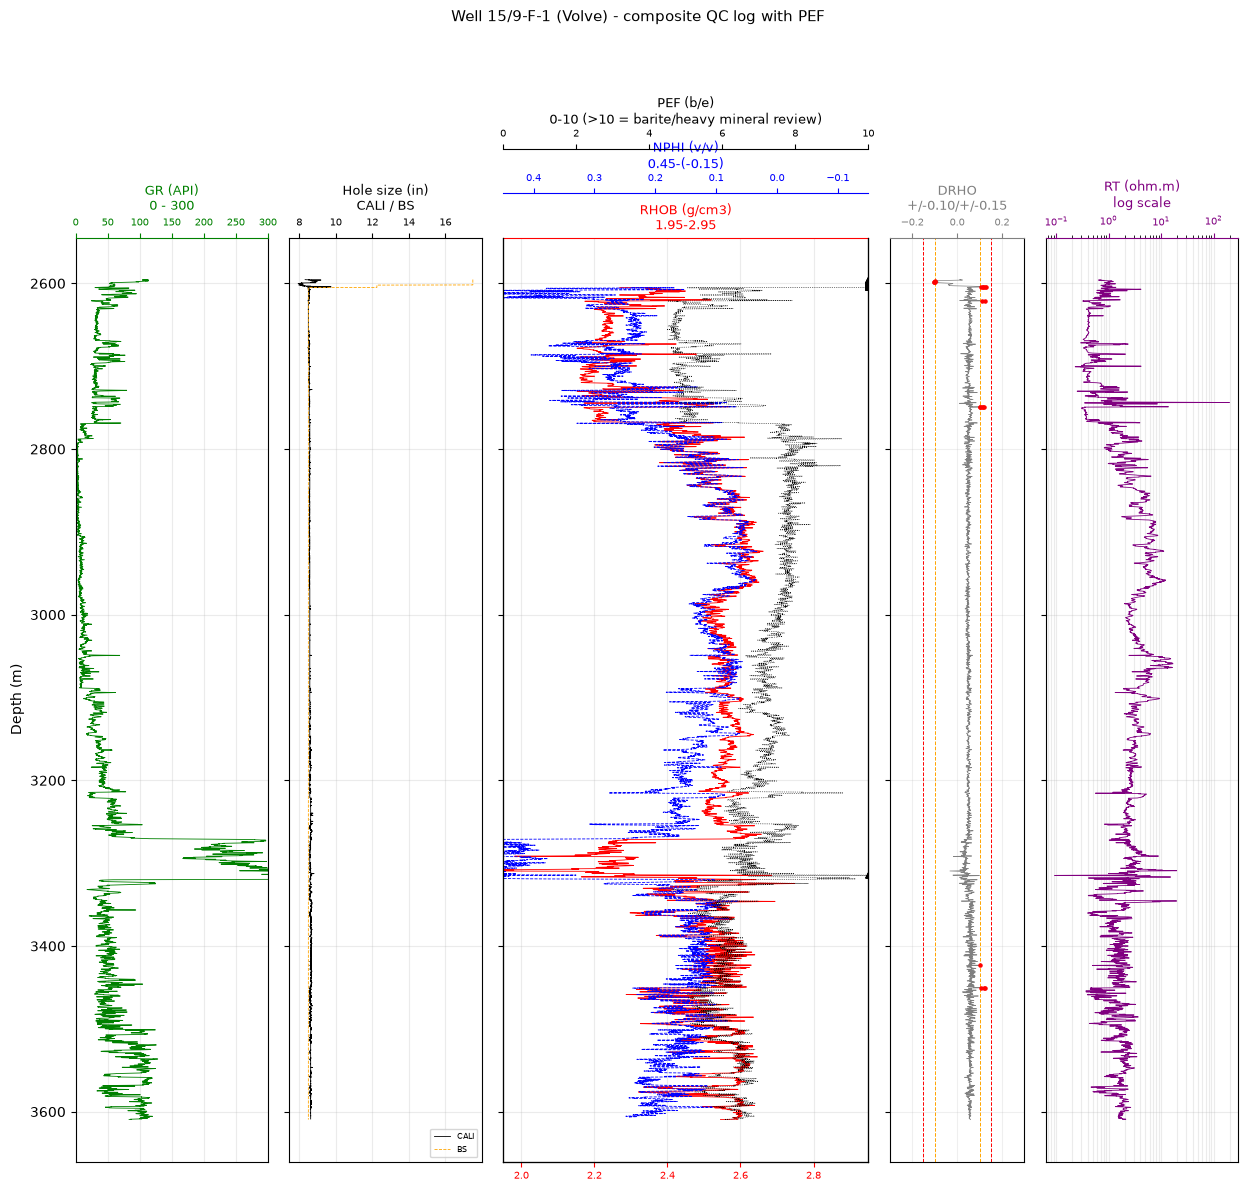

In [20]:
### QC visual: composite log with RHOB-NPHI-PEF overlay and DRHO cross-check

import matplotlib.gridspec as gridspec

plot_data_available = qc_df[["CALI", "DRHO", "RHOB", "NPHI"]].notna().any(axis=1)
qc_plot_df = qc_df.loc[plot_data_available].copy()
depth = qc_plot_df["DEPTH"]

fig = plt.figure(figsize=(15, 12))
gs = gridspec.GridSpec(1, 5, width_ratios=[1, 1, 1.9, 0.7, 1], wspace=0.10)
ax_gr = fig.add_subplot(gs[0])
ax_cali = fig.add_subplot(gs[1], sharey=ax_gr)
ax_rhob = fig.add_subplot(gs[2], sharey=ax_gr)
ax_drho = fig.add_subplot(gs[3], sharey=ax_gr)
ax_rt = fig.add_subplot(gs[4], sharey=ax_gr)

def header(ax, label, color, extra_pad=0):
    ax.xaxis.set_label_position("top")
    ax.xaxis.tick_top()
    ax.set_xlabel(label, color=color, fontsize=9, labelpad=6 + extra_pad)
    ax.tick_params(axis="x", colors=color, labelsize=7)
    ax.spines["top"].set_color(color)

# --- Track 1: GR ---
ax_gr.plot(qc_plot_df["GR"], depth, color="green", linewidth=0.6)
ax_gr.set_xlim(0, 300)
header(ax_gr, "GR (API)\n0 - 300", "green")
ax_gr.set_ylabel("Depth (m)")
ax_gr.grid(alpha=0.25)

# --- Track 2: Borehole ---
ax_cali.plot(qc_plot_df["CALI"], depth, color="black", linewidth=0.6, label="CALI")
ax_cali.plot(qc_plot_df["BS"], depth, color="orange", linewidth=0.6, linestyle="--", label="BS")
header(ax_cali, "Hole size (in)\nCALI / BS", "black")
ax_cali.legend(fontsize=6, loc="lower right")
ax_cali.tick_params(axis="y", labelleft=False)
ax_cali.grid(alpha=0.25)

# --- Track 3: RHOB-NPHI-PEF overlay, industry-standard scales ---
ax_rhob.plot(qc_plot_df["RHOB"], depth, color="red", linewidth=0.6)
ax_rhob.set_xlim(1.95, 2.95)
header(ax_rhob, "RHOB (g/cm3)\n1.95-2.95", "red")
ax_rhob.tick_params(axis="y", labelleft=False)
ax_rhob.grid(alpha=0.25)

ax_nphi = ax_rhob.twiny()
ax_nphi.plot(qc_plot_df["NPHI"], depth, color="blue", linewidth=0.6, linestyle="--")
ax_nphi.set_xlim(0.45, -0.15)
ax_nphi.xaxis.set_label_position("top")
ax_nphi.xaxis.tick_top()
ax_nphi.spines["top"].set_position(("outward", 32))
ax_nphi.spines["top"].set_color("blue")
ax_nphi.set_xlabel("NPHI (v/v)\n0.45-(-0.15)", color="blue", fontsize=9)
ax_nphi.tick_params(axis="x", colors="blue", labelsize=7)

# --- Track 3c: PEF as a third overlaid curve, stacked further out ---
ax_pef = ax_rhob.twiny()
ax_pef.plot(qc_plot_df["PEF"], depth, color="black", linewidth=0.5, linestyle=":")
ax_pef.set_xlim(0, 10)
ax_pef.xaxis.set_label_position("top")
ax_pef.xaxis.tick_top()
ax_pef.spines["top"].set_position(("outward", 64))
ax_pef.spines["top"].set_color("black")
ax_pef.set_xlabel("PEF (b/e)\n0-10 (>10 = barite/heavy mineral review)", color="black", fontsize=9)
ax_pef.tick_params(axis="x", colors="black", labelsize=7)
pef_elevated = qc_plot_df["PEF"] > PEF_HEAVY_MINERAL_LIMIT
ax_pef.scatter(
    qc_plot_df.loc[pef_elevated, "PEF"].clip(upper=10), depth[pef_elevated],
    color="black", marker="^", s=12, zorder=6, label="PEF off-scale (>10)"
)

# --- Track 4: DRHO QC sub-track, same y-axis, right next to RHOB-NPHI-PEF ---
ax_drho.plot(qc_plot_df["DRHO"], depth, color="gray", linewidth=0.5)
ax_drho.axvline(DRHO_CAUTION_LIMIT, color="orange", linestyle="--", linewidth=0.7)
ax_drho.axvline(-DRHO_CAUTION_LIMIT, color="orange", linestyle="--", linewidth=0.7)
ax_drho.axvline(DRHO_POOR_LIMIT, color="red", linestyle="--", linewidth=0.7)
ax_drho.axvline(-DRHO_POOR_LIMIT, color="red", linestyle="--", linewidth=0.7)
drho_concern = qc_plot_df["DRHO"].abs() > DRHO_CAUTION_LIMIT
ax_drho.scatter(qc_plot_df.loc[drho_concern, "DRHO"], depth[drho_concern], color="red", s=5, zorder=5)
ax_drho.set_xlim(-0.3, 0.3)
header(ax_drho, "DRHO\n+/-0.10/+/-0.15", "gray")
ax_drho.tick_params(axis="y", labelleft=False)
ax_drho.grid(alpha=0.2)

# --- Track 5: RT, log scale ---
positive_rt = qc_plot_df["RT"] > 0
ax_rt.plot(qc_plot_df.loc[positive_rt, "RT"], depth[positive_rt], color="purple", linewidth=0.6)
ax_rt.set_xscale("log")
header(ax_rt, "RT (ohm.m)\nlog scale", "purple")
ax_rt.tick_params(axis="y", labelleft=False)
ax_rt.grid(alpha=0.25, which="both")

ax_gr.invert_yaxis()
fig.suptitle("Well 15/9-F-1 (Volve) - composite QC log with PEF", y=1.07, fontsize=11)

plt.savefig(IMAGES_DIR / "qc_overview_log_panel.png", dpi=300, bbox_inches="tight")
plt.show()

# 7. Density–neutron QC diagnostic

This crossplot is used to distinguish measurements that passed borehole and density QC from measurements affected by QC concerns.

It does **not** prove gas or lithology. Density–neutron separation may reflect:

- gas;
- lithology;
- shale;
- washout;
- tool standoff;
- density-correction problems.

Points that pass the QC screen remain geological or fluid candidates for Notebook 2. Points with QC concerns must be treated cautiously.


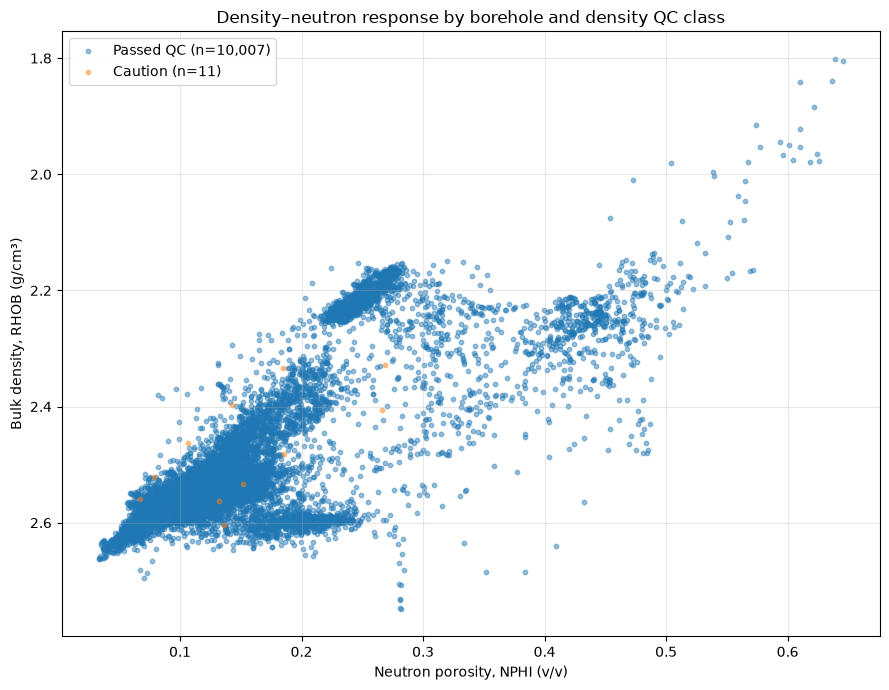

In [21]:
# Cell 16: Plot RHOB versus NPHI by density-reliability class

crossplot_df = qc_df.dropna(
    subset=[
        "RHOB",
        "NPHI"
    ]
).copy()

plt.figure(figsize=(9, 7))

for reliability_class in [
    "Passed QC",
    "Caution",
    "Strong QC concern",
    "Limited QC — supporting curves missing"
]:

    group = crossplot_df.loc[
        crossplot_df["DENSITY_RELIABILITY"]
        ==
        reliability_class
    ]

    if not group.empty:
        plt.scatter(
            group["NPHI"],
            group["RHOB"],
            s=10,
            alpha=0.45,
            label=(
                f"{reliability_class} "
                f"(n={len(group):,})"
            )
        )

plt.xlabel("Neutron porosity, NPHI (v/v)")
plt.ylabel("Bulk density, RHOB (g/cm³)")
plt.title(
    "Density–neutron response by borehole and density QC class"
)

# Density plots are commonly displayed with lower density at the top.
plt.gca().invert_yaxis()

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    IMAGES_DIR / "density_neutron_qc_crossplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### How to read the density–neutron crossplot

A point with density–neutron separation is not automatically gas.

- If the point also has poor caliper or DRHO QC, the separation may come from measurement conditions.
- If the point passes QC, it remains a geological or fluid candidate.

Notebook 2 will use lithology, gamma ray, resistivity and calculated porosity before making a fluid interpretation.

# 8. Compare the resistivity curves

The LAS file contains several resistivity-related curves. This section compares every pair over their common valid interval.

The aim is to identify:

- exact duplicates;
- near duplicates;
- strongly related but non-identical curves.

Duplicated curves are not treated as independent evidence in later interpretation.


In [22]:
# Cell 17: Compare all resistivity-curve pairs

resistivity_curves = [
    "RACEHM",
    "RACELM",
    "RD",
    "RM",
    "RPCEHM",
    "RPCELM",
    "RT"
]

comparison_rows = []

for position, curve_a in enumerate(resistivity_curves):

    for curve_b in resistivity_curves[
        position + 1:
    ]:

        pair_data = qc_df[
            [
                curve_a,
                curve_b
            ]
        ].dropna()

        if pair_data.empty:
            continue

        values_a = pair_data[curve_a].to_numpy()
        values_b = pair_data[curve_b].to_numpy()

        positive_pair_mask = (
            (values_a > 0)
            &
            (values_b > 0)
        )

        if positive_pair_mask.sum() > 1:
            log10_correlation = np.corrcoef(
                np.log10(
                    values_a[
                        positive_pair_mask
                    ]
                ),
                np.log10(
                    values_b[
                        positive_pair_mask
                    ]
                )
            )[0, 1]
        else:
            log10_correlation = np.nan

        absolute_difference = np.abs(
            values_a
            -
            values_b
        )

        comparison_scale = np.maximum(
            np.abs(values_a),
            np.abs(values_b)
        )

        valid_relative_difference = (
            comparison_scale > 0
        )

        relative_difference_percent = np.full(
            len(pair_data),
            np.nan
        )

        relative_difference_percent[
            valid_relative_difference
        ] = (
            absolute_difference[
                valid_relative_difference
            ]
            /
            comparison_scale[
                valid_relative_difference
            ]
            *
            100
        )

        exact_duplicate = np.allclose(
            values_a,
            values_b,
            rtol=0,
            atol=0
        )

        near_duplicate = np.allclose(
            values_a,
            values_b,
            rtol=1e-4,
            atol=1e-4
        )

        if exact_duplicate:
            relationship = "Exact duplicate"
        elif near_duplicate:
            relationship = "Near duplicate"
        elif (
            pd.notna(log10_correlation)
            and log10_correlation >= 0.999
            and np.nanmedian(relative_difference_percent) < 1.0
        ):
            relationship = "Effectively the same response"
        elif (
            pd.notna(log10_correlation)
            and log10_correlation >= 0.95
        ):
            relationship = "Strongly related response"
        else:
            relationship = "Different response"

        comparison_rows.append(
            {
                "CURVE_A": curve_a,
                "CURVE_B": curve_b,
                "OVERLAPPING_SAMPLES": len(pair_data),
                "RAW_VALUE_CORRELATION": pair_data[
                    curve_a
                ].corr(
                    pair_data[curve_b]
                ),
                "LOG10_CORRELATION": log10_correlation,
                "MEAN_ABSOLUTE_DIFFERENCE": np.mean(
                    absolute_difference
                ),
                "MEDIAN_RELATIVE_DIFFERENCE_PERCENT": np.nanmedian(
                    relative_difference_percent
                ),
                "MAXIMUM_ABSOLUTE_DIFFERENCE": np.max(
                    absolute_difference
                ),
                "EXACT_DUPLICATE": exact_duplicate,
                "NEAR_DUPLICATE": near_duplicate,
                "RELATIONSHIP": relationship
            }
        )

resistivity_comparison = pd.DataFrame(
    comparison_rows
)

resistivity_comparison = (
    resistivity_comparison
    .sort_values(
        [
            "EXACT_DUPLICATE",
            "NEAR_DUPLICATE",
            "LOG10_CORRELATION"
        ],
        ascending=[
            False,
            False,
            False
        ]
    )
    .reset_index(drop=True)
)

resistivity_comparison.to_csv(
    RESULTS_DIR / "resistivity_curve_comparison.csv",
    index=False
)

duplicate_resistivity_candidates = (
    resistivity_comparison.loc[
        resistivity_comparison[
            "RELATIONSHIP"
        ].isin(
            [
                "Exact duplicate",
                "Near duplicate",
                "Effectively the same response"
            ]
        )
    ]
)

duplicate_resistivity_candidates

,CURVE_A,CURVE_B,OVERLAPPING_SAMPLES,RAW_VALUE_CORRELATION,LOG10_CORRELATION,MEAN_ABSOLUTE_DIFFERENCE,MEDIAN_RELATIVE_DIFFERENCE_PERCENT,MAXIMUM_ABSOLUTE_DIFFERENCE,EXACT_DUPLICATE,NEAR_DUPLICATE,RELATIONSHIP
0,RPCEHM,RT,33810,1.0,1.0,0.000000,0.0,0.0000,True,True,Exact duplicate
1,RD,RPCELM,33709,1.0,1.0,0.000002,0.0,0.0001,False,True,Near duplicate
2,RM,RPCEHM,33709,1.0,1.0,0.000004,0.0,0.0059,False,False,Effectively the same response
3,RM,RT,33709,1.0,1.0,0.000004,0.0,0.0059,False,False,Effectively the same response


## Primary resistivity decision

`RT` is the primary resistivity input for the later formation-evaluation notebook because it is the supplied composite resistivity curve.

Other resistivity curves are retained in the exported QC dataset for comparison. This notebook does not delete duplicated curves.


### What the resistivity comparison means in simple English

The file contains several resistivity columns, but some are copies or near copies. Counting the same response several times would create false confidence. The comparison identifies repeated information while keeping every original column in the QC export.

# 9. Mark rows suitable for later petrophysical interpretation

The main later calculations require:

- `GR`;
- `RHOB`;
- `NPHI`;
- `RT`.

A row is marked **interpretation ready** when:

1. all four required curves are present;
2. resistivity is positive;
3. density passed the full borehole and DRHO QC screen.

Broad numerical range flags remain attached for review, but no rows are deleted.


In [23]:
# Cell 18: Create interpretation-availability and readiness flags

required_interpretation_curves = [
    "GR",
    "RHOB",
    "NPHI",
    "RT"
]

qc_df["REQUIRED_LOGS_AVAILABLE"] = (
    qc_df[
        required_interpretation_curves
    ]
    .notna()
    .all(axis=1)
)

qc_df["RT_VALID_FLAG"] = (
    qc_df["RT"].notna()
    &
    (qc_df["RT"] > 0)
)

primary_range_flags = [
    "GR_RANGE_REVIEW_FLAG",
    "RHOB_RANGE_REVIEW_FLAG",
    "NPHI_RANGE_REVIEW_FLAG",
    "RT_RANGE_REVIEW_FLAG"
]

qc_df["PRIMARY_RANGE_REVIEW_FLAG"] = (
    qc_df[
        primary_range_flags
    ]
    .fillna(False)
    .any(axis=1)
)

primary_spike_flags = [
    "GR_LOCAL_SPIKE_REVIEW_FLAG",
    "RHOB_LOCAL_SPIKE_REVIEW_FLAG",
    "NPHI_LOCAL_SPIKE_REVIEW_FLAG",
    "RT_LOCAL_SPIKE_REVIEW_FLAG"
]

qc_df["PRIMARY_LOCAL_SPIKE_REVIEW_FLAG"] = (
    qc_df[
        primary_spike_flags
    ]
    .fillna(False)
    .any(axis=1)
)

# Candidate means the minimum logs exist and RT is mathematically usable.
# Ready applies the stricter density-reliability requirement.
qc_df["INTERPRETATION_CANDIDATE_FLAG"] = (
    qc_df["REQUIRED_LOGS_AVAILABLE"]
    &
    qc_df["RT_VALID_FLAG"]
)

qc_df["INTERPRETATION_READY_FLAG"] = (
    qc_df["INTERPRETATION_CANDIDATE_FLAG"]
    &
    (
        qc_df["DENSITY_RELIABILITY"]
        ==
        "Passed QC"
    )
)

qc_df["INTERPRETATION_STATUS"] = (
    "Not ready — required log(s) missing"
)

qc_df.loc[
    qc_df["REQUIRED_LOGS_AVAILABLE"]
    &
    ~qc_df["RT_VALID_FLAG"],
    "INTERPRETATION_STATUS"
] = "Not ready — non-positive resistivity"

qc_df.loc[
    qc_df["INTERPRETATION_CANDIDATE_FLAG"]
    &
    (
        qc_df["DENSITY_RELIABILITY"]
        ==
        "Strong QC concern"
    ),
    "INTERPRETATION_STATUS"
] = "Review — strong density QC concern"

qc_df.loc[
    qc_df["INTERPRETATION_CANDIDATE_FLAG"]
    &
    (
        qc_df["DENSITY_RELIABILITY"]
        ==
        "Caution"
    ),
    "INTERPRETATION_STATUS"
] = "Review — density QC caution"

qc_df.loc[
    qc_df["INTERPRETATION_CANDIDATE_FLAG"]
    &
    (
        qc_df["DENSITY_RELIABILITY"]
        ==
        "Limited QC — supporting curves missing"
    ),
    "INTERPRETATION_STATUS"
] = "Review — density QC incomplete"

qc_df.loc[
    qc_df["INTERPRETATION_READY_FLAG"],
    "INTERPRETATION_STATUS"
] = "Ready for interpretation"

qc_df.loc[
    qc_df["INTERPRETATION_READY_FLAG"]
    &
    (
        qc_df["PRIMARY_RANGE_REVIEW_FLAG"]
        |
        qc_df["PRIMARY_LOCAL_SPIKE_REVIEW_FLAG"]
    ),
    "INTERPRETATION_STATUS"
] = "Ready, but review flag carried forward"

interpretation_status_summary = (
    qc_df[
        "INTERPRETATION_STATUS"
    ]
    .value_counts()
    .rename_axis(
        "INTERPRETATION_STATUS"
    )
    .reset_index(
        name="ROW_COUNT"
    )
)

interpretation_status_summary

,INTERPRETATION_STATUS,ROW_COUNT
0,Not ready — required log(s) missing,24843
1,Ready for interpretation,9561
2,"Ready, but review flag carried forward",446
3,Review — density QC caution,11


In [24]:
# Cell 19: Summarise the usable interpretation interval

required_logs_mask = qc_df[
    "REQUIRED_LOGS_AVAILABLE"
]

candidate_mask = qc_df[
    "INTERPRETATION_CANDIDATE_FLAG"
]

ready_mask = qc_df[
    "INTERPRETATION_READY_FLAG"
]

interpretation_readiness_summary = pd.DataFrame(
    {
        "MEASURE": [
            "Total LAS rows",
            "Rows with GR, RHOB, NPHI and RT",
            "First depth with all four required curves (m)",
            "Last depth with all four required curves (m)",
            "Rows that are calculation candidates",
            "Rows passing the interpretation-ready screen",
            "First interpretation-ready depth (m)",
            "Last interpretation-ready depth (m)"
        ],
        "VALUE": [
            len(qc_df),
            int(required_logs_mask.sum()),
            qc_df.loc[
                required_logs_mask,
                "DEPTH"
            ].min(),
            qc_df.loc[
                required_logs_mask,
                "DEPTH"
            ].max(),
            int(candidate_mask.sum()),
            int(ready_mask.sum()),
            qc_df.loc[
                ready_mask,
                "DEPTH"
            ].min(),
            qc_df.loc[
                ready_mask,
                "DEPTH"
            ].max()
        ]
    }
)

interpretation_readiness_summary

,MEASURE,VALUE
0,Total LAS rows,34861.0
1,"Rows with GR, RHOB, NPHI and RT",10018.0
2,First depth with all four required curves (m),2605.0
3,Last depth with all four required curves (m),3606.7
4,Rows that are calculation candidates,10018.0
5,Rows passing the interpretation-ready screen,10007.0
6,First interpretation-ready depth (m),2605.0
7,Last interpretation-ready depth (m),3606.7


### What “interpretation ready” means in simple English

A row is “ready” only when the main measurements exist, resistivity is usable, and density passed the borehole and DRHO checks.

“Ready” does not mean the geology has already been interpreted. It means the row has passed the entrance checklist for Notebook 2. Review flags remain attached so later calculations can be tested with and without questionable points.

# 10. Export the QC results

Two datasets are exported:

1. `well_log_qc_flagged.csv` — all original curves plus every QC flag.
2. `formation_evaluation_input.csv` — rows where the four main interpretation curves exist, while still retaining QC concerns and flags.

The second file is not a “perfectly clean” dataset. It intentionally carries the QC evidence into Notebook 2.


In [25]:
# Cell 20: Export tables and flagged data

# Full QC dataset: no raw rows are deleted.
qc_df.to_csv(
    RESULTS_DIR / "well_log_qc_flagged.csv",
    index=False
)

# Formation-evaluation input:
# retain every row containing the four required logs.
# QC flags remain attached so Notebook 2 can compare passed and questionable intervals.
formation_evaluation_input = qc_df.loc[
    qc_df["REQUIRED_LOGS_AVAILABLE"]
].copy()

formation_evaluation_input.to_csv(
    RESULTS_DIR / "formation_evaluation_input.csv",
    index=False
)

depth_qc_summary.to_csv(
    RESULTS_DIR / "depth_qc_summary.csv",
    index=False
)

unit_qc.to_csv(
    RESULTS_DIR / "unit_qc_summary.csv",
    index=False
)

metadata_limitations.to_csv(
    RESULTS_DIR / "metadata_limitations.csv",
    index=False
)

hard_validity_summary.to_csv(
    RESULTS_DIR / "hard_validity_summary.csv",
    index=False
)

range_review_summary.to_csv(
    RESULTS_DIR / "range_review_summary.csv",
    index=False
)

local_spike_summary.to_csv(
    RESULTS_DIR / "local_spike_review_summary.csv",
    index=False
)

borehole_density_qc_summary.to_csv(
    RESULTS_DIR / "borehole_density_qc_summary.csv",
    index=False
)

interpretation_status_summary.to_csv(
    RESULTS_DIR / "interpretation_status_summary.csv",
    index=False
)

interpretation_readiness_summary.to_csv(
    RESULTS_DIR / "interpretation_readiness_summary.csv",
    index=False
)

# Prove that the raw dataframe was not shortened or overwritten.
raw_data_integrity_check = pd.DataFrame(
    {
        "CHECK": [
            "Raw row count unchanged",
            "Raw column names unchanged",
            "QC dataframe retains all raw rows"
        ],
        "PASSED": [
            len(raw_df) == RAW_ROW_COUNT,
            raw_df.columns.tolist() == RAW_COLUMN_NAMES,
            len(qc_df) == RAW_ROW_COUNT
        ]
    }
)

raw_data_integrity_check.to_csv(
    RESULTS_DIR / "raw_data_integrity_check.csv",
    index=False
)

print("Files exported successfully:")
print(RESULTS_DIR / "well_log_qc_flagged.csv")
print(RESULTS_DIR / "formation_evaluation_input.csv")
print(RESULTS_DIR / "curve_inventory_and_coverage.csv")
print(RESULTS_DIR / "resistivity_curve_comparison.csv")
print(IMAGES_DIR / "qc_overview_log_panel.png")
print(RESULTS_DIR / "raw_data_integrity_check.csv")

raw_data_integrity_check

Files exported successfully:
results\well_log_qc_flagged.csv
results\formation_evaluation_input.csv
results\curve_inventory_and_coverage.csv
results\resistivity_curve_comparison.csv
images\qc_overview_log_panel.png
results\raw_data_integrity_check.csv


,CHECK,PASSED
0,Raw row count unchanged,True
1,Raw column names unchanged,True
2,QC dataframe retains all raw rows,True


# 11. Final answers from Notebook 1

The final table below directly answers the eight QC questions set at the beginning of the notebook.


In [26]:
# Cell 21: Build a final recruiter-friendly QC answer table

internal_gap_curves = curve_coverage.loc[
    curve_coverage["INTERNAL_MISSING_COUNT"] > 0,
    "CURVE"
].tolist()

duplicate_pairs = resistivity_comparison.loc[
    resistivity_comparison["RELATIONSHIP"].isin(
        [
            "Exact duplicate",
            "Near duplicate",
            "Effectively the same response"
        ]
    ),
    [
        "CURVE_A",
        "CURVE_B",
        "RELATIONSHIP"
    ]
]

if duplicate_pairs.empty:
    duplicate_text = "No duplicate or effectively duplicate pairs detected"
else:
    duplicate_text = "; ".join(
        duplicate_pairs.apply(
            lambda row: (
                f"{row['CURVE_A']} and "
                f"{row['CURVE_B']} "
                f"({row['RELATIONSHIP'].lower()})"
            ),
            axis=1
        )
    )

ready_depths = qc_df.loc[
    qc_df["INTERPRETATION_READY_FLAG"],
    "DEPTH"
]

hole_counts = (
    qc_df.loc[
        qc_df["BOREHOLE_QC_AVAILABLE"],
        "HOLE_CONDITION"
    ]
    .value_counts()
)

density_counts = (
    qc_df.loc[
        qc_df["RHOB"].notna(),
        "DENSITY_RELIABILITY"
    ]
    .value_counts()
)

qc_answers = pd.DataFrame(
    {
        "QUESTION": [
            "What curves are available?",
            "At what depths are they available?",
            "Are there missing values?",
            "Is the borehole enlarged?",
            "Can the density measurement be trusted?",
            "Are density–neutron anomalies geological or caused by poor borehole conditions?",
            "Which resistivity curves duplicate one another?",
            "Which rows are suitable for later interpretation?"
        ],
        "ANSWER": [
            (
                f"{raw_df.shape[1]} curves/columns loaded. "
                "See curve_inventory_and_coverage.csv for names, units and roles."
            ),
            (
                "Each curve's first and last valid depth is reported "
                "in the curve-coverage table."
            ),
            (
                f"Internal gaps occur in: "
                f"{', '.join(internal_gap_curves) if internal_gap_curves else 'none'}."
            ),
            (
                f"{int(hole_counts.get('Enlarged hole / washout candidate', 0)):,} "
                "rows are enlarged-hole candidates; "
                f"{int(hole_counts.get('Under-gauge / mudcake or swelling candidate', 0)):,} "
                "are moderate under-gauge candidates; and "
                f"{int(hole_counts.get('Major CALI–BS mismatch / section-transition candidate', 0)):,} "
                "have a major CALI–BS mismatch."
            ),
            (
                f"{int(density_counts.get('Passed QC', 0)):,} "
                "density rows passed full QC; "
                f"{int(density_counts.get('Caution', 0)):,} "
                "are caution; "
                f"{int(density_counts.get('Strong QC concern', 0)):,} "
                "have a strong concern."
            ),
            (
                "The crossplot separates borehole/density-QC concerns from "
                "passed-QC points. Passed-QC anomalies remain geological or "
                "fluid candidates for Notebook 2; QC alone cannot prove gas."
            ),
            duplicate_text,
            (
                f"{int(qc_df['INTERPRETATION_READY_FLAG'].sum()):,} rows are "
                f"interpretation ready, spanning "
                f"{ready_depths.min():.1f}–{ready_depths.max():.1f} m."
                if not ready_depths.empty
                else
                "No rows passed the current interpretation-ready screen."
            )
        ]
    }
)

qc_answers.to_csv(
    RESULTS_DIR / "qc_answers_summary.csv",
    index=False
)

qc_answers

,QUESTION,ANSWER
0,What curves are available?,"21 curves/columns loaded. See curve_inventory_and_coverage.csv for names, units and roles."
1,At what depths are they available?,Each curve's first and last valid depth is reported in the curve-coverage table.
2,Are there missing values?,"Internal gaps occur in: GR, RACEHM, RACELM, RD, RM, ROP, RPCEHM, RPCELM, RT."
3,Is the borehole enlarged?,0 rows are enlarged-hole candidates; 0 are moderate under-gauge candidates; and 96 have a major CALI–BS mismatch.
4,Can the density measurement be trusted?,"10,028 density rows passed full QC; 11 are caution; 0 have a strong concern."
5,Are density–neutron anomalies geological or caused by poor borehole conditions?,The crossplot separates borehole/density-QC concerns from passed-QC points. Passed-QC anomalies remain geological or fluid candidates for Notebook 2; QC alone cannot prove gas.
6,Which resistivity curves duplicate one another?,RPCEHM and RT (exact duplicate); RD and RPCELM (near duplicate); RM and RPCEHM (effectively the same response); RM and RT (effectively the same response)
7,Which rows are suitable for later interpretation?,"10,007 rows are interpretation ready, spanning 2605.0–3606.7 m."


In [27]:
# Create a simple, copy-paste README summary using the actual QC results

ready_depths = qc_df.loc[
    qc_df["INTERPRETATION_READY_FLAG"],
    "DEPTH"
]

readme_summary = f"""## Notebook 1 — Well-log data loading and quality control

This notebook checks whether the well-log measurements are reliable enough to
interpret before calculating shale volume, porosity or water saturation.

The workflow preserves the raw LAS data, checks depth continuity, records the
coverage and missing gaps of every curve, validates units, screens unusual
values, compares caliper with bit size, evaluates density reliability using
DRHO and borehole condition, reviews density–neutron behaviour, and identifies
duplicated resistivity curves.

### Main QC results

- Raw rows preserved: {len(raw_df):,}
- Curves/columns loaded: {raw_df.shape[1]}
- Rows with GR, RHOB, NPHI and RT: {int(qc_df['REQUIRED_LOGS_AVAILABLE'].sum()):,}
- Rows passing the interpretation-ready screen: {int(qc_df['INTERPRETATION_READY_FLAG'].sum()):,}
- Interpretation-ready depth range: {
    f"{ready_depths.min():.1f}–{ready_depths.max():.1f} m"
    if not ready_depths.empty
    else "No rows passed the current screen"
}

### Important rule

A QC flag does not automatically mean that a measurement is wrong. It means
that the value needs additional review. Likewise, passing QC does not prove a
gas, oil or lithology interpretation. Those decisions are made in the later
formation-evaluation notebook using several curves and geological context.

No raw measurements were deleted. All warnings remain attached to the data so
that the workflow is transparent and auditable.
"""

readme_path = RESULTS_DIR / "README_notebook_1_summary.md"

readme_path.write_text(
    readme_summary,
    encoding="utf-8"
)

print(readme_summary)
print(f"\nREADME section saved to: {readme_path}")

## Notebook 1 — Well-log data loading and quality control

This notebook checks whether the well-log measurements are reliable enough to
interpret before calculating shale volume, porosity or water saturation.

The workflow preserves the raw LAS data, checks depth continuity, records the
coverage and missing gaps of every curve, validates units, screens unusual
values, compares caliper with bit size, evaluates density reliability using
DRHO and borehole condition, reviews density–neutron behaviour, and identifies
duplicated resistivity curves.

### Main QC results

- Raw rows preserved: 34,861
- Curves/columns loaded: 21
- Rows with GR, RHOB, NPHI and RT: 10,018
- Rows passing the interpretation-ready screen: 10,007
- Interpretation-ready depth range: 2605.0–3606.7 m

### Important rule

A QC flag does not automatically mean that a measurement is wrong. It means
that the value needs additional review. Likewise, passing QC does not prove a
gas, oil or lithology interpretation. Those dec

## Technical basis and scope

The QC logic follows a measurement-first principle: understand what each tool measures, identify borehole and acquisition effects, state assumptions, and only then interpret rock and fluid properties.

Technical references used:

- Ellis, D. V. and Singer, J. M. (2007), *Well Logging for Earth Scientists*, 2nd edition, Springer.
- Glover, P. W. J., *Petrophysics MSc Course Notes*: Porosity; Permeability; Borehole Environment; Caliper Logs; Total and Spectral Gamma Ray; Formation Density; Litho-Density; Neutron; Sonic; Resistivity Theory; and Clay/Shale Effects.

The uploaded SP and spectral-gamma chapters were reviewed, but this LAS file does not contain SP, SGR, CGR, potassium, uranium or thorium curves. Empty QC calculations were therefore not added for measurements that are absent.

## Notebook 1 completion rule

Notebook 1 is complete when:

- the notebook runs from top to bottom without errors;
- every curve has a documented unit, role and coverage interval;
- internal missing gaps are distinguished from unlogged intervals;
- depth, borehole and density QC flags have been created;
- density–neutron points are classified by QC reliability;
- duplicated resistivity curves have been identified;
- the full flagged dataset and formation-evaluation input have been exported.

No shale-volume, porosity, water-saturation, net-reservoir or net-pay calculations belong in this notebook. Those begin in Notebook 2.
